# PCA + Logistic Regression

In [1]:
Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)
garnet <- "#6B0D0E"
gold   <- "#F8C23A"

### Split X and Y

In [2]:
train_data <- read.csv("../Pima-Indians-Diabetes-Dataset/train_data_imputed.csv")
test_data <- read.csv("../Pima-Indians-Diabetes-Dataset/test_data_imputed.csv")

In [3]:
train_x <- subset(train_data, select = -Outcome)
train_y <- train_data$Outcome

test_x <- subset(test_data, select = -Outcome)
test_y <- test_data$Outcome

### Z-Score Scaling

In [4]:
# Calculate mean and sd from TRAINING DATA ONLY
train_mean <- apply(train_x, 2, mean)
train_sd <- apply(train_x, 2, sd)

In [5]:
# Scale training data
train_scaled <- scale(
  train_x,
  center = train_mean,
  scale = train_sd
)

In [6]:
# Scale testing data using TRAINING statistics
test_scaled <- scale(
  test_x,
  center = train_mean,
  scale = train_sd
)

### PCA

In [7]:
pca_model <- prcomp(
  train_scaled,
  center = FALSE,
  scale. = FALSE
)

# Variance explained
summary(pca_model)

Importance of components:
                          PC1    PC2    PC3    PC4     PC5     PC6     PC7
Standard deviation     1.5506 1.2189 1.0539 0.9532 0.86925 0.70669 0.67831
Proportion of Variance 0.3006 0.1857 0.1388 0.1136 0.09445 0.06243 0.05751
Cumulative Proportion  0.3006 0.4863 0.6251 0.7387 0.83314 0.89557 0.95308
                           PC8
Standard deviation     0.61268
Proportion of Variance 0.04692
Cumulative Proportion  1.00000

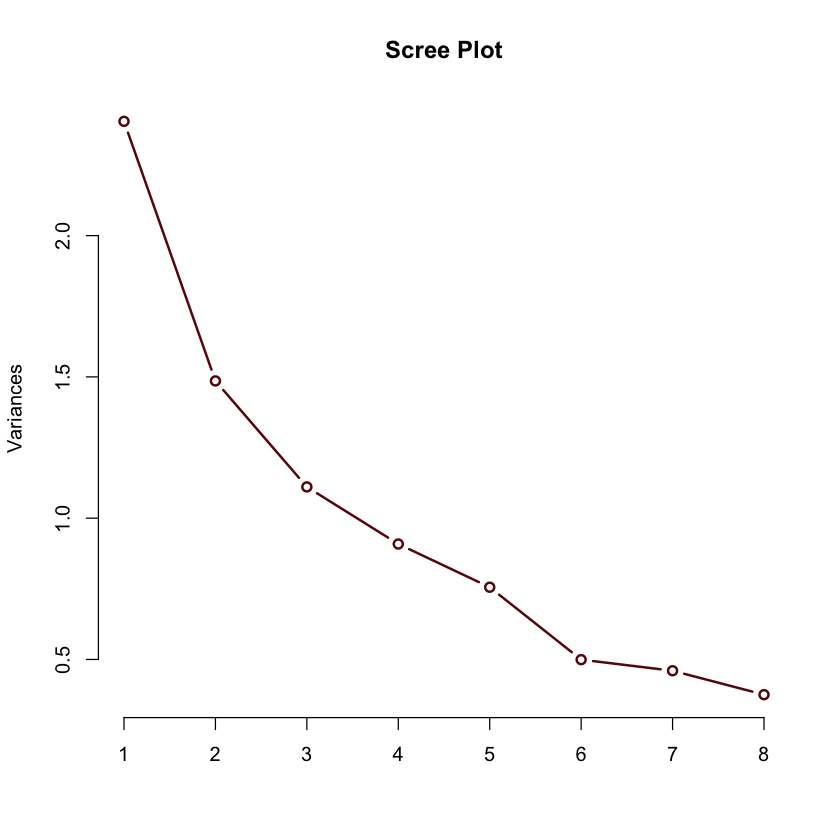

In [8]:
# Scree Plot
par(bg = "white")

plot(
  pca_model,
  type = "l",
  col = Garnet,      # Line color
  lwd = 2,           # Line width
  main = "Scree Plot"
)

### Transform Data

In [9]:
train_pca <- predict(
  pca_model,
  newdata = train_scaled
)

test_pca <- predict(
  pca_model,
  newdata = test_scaled
)

### Select First 5 PCs

In [10]:
num_pc <- 5

train_pca_df <- data.frame(
  train_pca[, 1:num_pc],
  Outcome = train_y
)

test_pca_df <- data.frame(
  test_pca[, 1:num_pc]
)


### Logistic Regression

In [11]:
head(train_pca_df)

,PC1,PC2,PC3,PC4,PC5,Outcome
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,-9.309023,0.3236229,2.428026,0.01500526,2.668193,1
2,-8.821492,0.4580744,2.884086,1.40453783,2.699233,0
3,-9.488882,1.3301312,1.177279,-2.38515283,3.189270,0
4,-9.577060,0.8437675,2.268840,-0.60458106,2.776101,0
5,-9.798597,1.7660156,1.215947,-2.74338591,3.414851,0
6,-9.123600,0.3886676,2.861147,0.96673823,2.700708,0


In [12]:
model <- glm(
  Outcome ~ .,
  data = train_pca_df,
  family = binomial
)

summary(model)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_pca_df)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 199.1649    19.0022  10.481  < 2e-16 ***
PC1          28.8175     2.7282  10.563  < 2e-16 ***
PC2          -6.1937     0.8397  -7.376 1.63e-13 ***
PC3          27.9813     3.2935   8.496  < 2e-16 ***
PC4         -19.6174     2.1544  -9.106  < 2e-16 ***
PC5           1.1421     1.1543   0.989    0.322    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 549.39  on 608  degrees of freedom
AIC: 561.39

Number of Fisher Scoring iterations: 5


In [13]:
BIC(model)

[1] 587.9056

### Prediction

In [14]:
prob <- predict(
  model,
  newdata = test_pca_df,
  type = "response"
)

pred <- ifelse(prob > 0.5, 1, 0)

In [15]:
cm <- table(
  Actual = test_y,
  Predicted = pred
)

cm

      Predicted
Actual  0  1
     0 89 13
     1 20 32

In [16]:
accuracy <- sum(diag(cm)) / sum(cm)

precision <- cm["1","1"] /
             (cm["0","1"] + cm["1","1"])

recall <- cm["1","1"] /
          (cm["1","0"] + cm["1","1"])

f1 <- 2 * precision * recall /
      (precision + recall)

cat("Accuracy =", round(accuracy,4), "\n")
cat("Precision =", round(precision,4), "\n")
cat("Recall =", round(recall,4), "\n")
cat("F1 Score =", round(f1,4), "\n")

Accuracy = 0.7857 
Precision = 0.7111 
Recall = 0.6154 
F1 Score = 0.6598 
